# 미니프로젝트: 머신러닝 프로세스 (Vibe Coding)

#### <목표>
오늘 배운 머신러닝 프로세스를 **제조 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- AI4I 2020 Predictive Maintenance (예지 정비)
- 10,000개 제조 장비 운전 데이터

| 변수명 | 설명 |
|:---:|:---|
| Type | 제품 품질 등급 (L: Low, M: Medium, H: High) |
| Air temperature | 공기 온도 [K] |
| Process temperature | 공정 온도 [K] |
| Rotational speed | 회전 속도 [rpm] |
| Torque | 토크 [Nm] |
| Tool wear | 공구 마모 시간 [min] |
| Machine failure | 기계 고장 여부 (0: 정상, 1: 고장) |
| TWF, HDF, PWF, OSF, RNF | 고장 유형별 발생 여부 |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 회귀 | `Torque` | 운전 조건(온도, 회전속도, 공구마모 등)으로 토크 예측 |
| 분류 | `Machine failure` | 운전 조건으로 기계 고장 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day1_miniproject.csv` 파일을 사용하기
- 하나의 원본 데이터에서 태스크별로 데이터프레임을 분리하기
    - **회귀용 (Regression):** 타겟 = `Torque`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Tool wear
    - **분류용 (Classification):** 타겟 = `Machine failure`, 입력 = Type, Air temperature, Process temperature, Rotational speed, Torque, Tool wear

**[과제]** 써니는 오늘부로 제조 설비 운전 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 불러오고, 회귀용/분류용 데이터셋을 각각 어떻게 구성해야 할지 AI와 상의해서 코드를 작성하세요.

In [11]:
import pandas as pd
import numpy as np 

# 데이터 탐색을 위한 주요 시각화 라이브러리 호출 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 그래프에 한글이 깨지거나(경고: Glyph ... missing from font(s) DejaVu Sans) 안 보이는 문제 방지
# Windows 기본 한글 폰트인 '맑은 고딕(Malgun Gothic)'으로 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False   # 한글 폰트 사용 시 마이너스(-) 기호가 깨지는 문제 방지

# 원본 데이터 불러오기
df = pd.read_csv('dataset/day1_miniproject.csv')

# 회귀용 데이터셋: 타겟 = Torque
reg_features = ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Tool wear']
reg_target = 'Torque'
df_reg = df[reg_features + [reg_target]].copy()

# 분류용 데이터셋: 타겟 = Machine failure
clf_features = ['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']
clf_target = 'Machine failure'
df_clf = df[clf_features + [clf_target]].copy()

print('회귀용 데이터셋:', df_reg.shape)
display(df_reg.head())

print('분류용 데이터셋:', df_clf.shape)
display(df_clf.head())

회귀용 데이터셋: (10000, 6)


,Type,Air temperature,Process temperature,Rotational speed,Tool wear,Torque
0,M,298.1,308.6,1551,0,42.8
1,L,298.2,308.7,1408,3,46.3
2,L,298.1,308.5,1498,5,49.4
3,L,298.2,308.6,1433,7,39.5
4,L,298.2,308.7,1408,9,40.0


분류용 데이터셋: (10000, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


---
## 1) 데이터 탐색 (EDA)

### 1-1) Value 기반 탐색

**[과제]** 써니는 본격적인 분석에 앞서 데이터가 어떻게 생겼는지 먼저 파악하고 싶습니다. AI와 어떠한 데이터 정보를 확인하면 좋을지 상의해보고 관련 정보를 확인해보세요.

In [13]:
# 데이터 크기 및 컬럼 구조 확인
print('shape:', df.shape)
df.head()

shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [15]:
# 컬럼별 데이터 타입 및 결측치 확인
df.info()
print('\n결측치 개수:')
print(df.isnull().sum())
print('\n중복 행 개수:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB

결측치 개수:
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque             

In [16]:
df.corr(numeric_only=True) # 상관계수

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
Air temperature,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556,0.009955,0.137831,0.003470,0.001988,0.017688
Process temperature,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946,0.007315,0.056933,-0.003355,0.004554,0.022279
Rotational speed,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188,0.010389,-0.121241,0.123018,-0.104575,-0.013088
Torque,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321,-0.014662,0.142610,0.083781,0.183465,0.016136
Tool wear,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448,0.115792,-0.001287,-0.009334,0.155894,0.011326
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000,0.362904,0.575800,0.522812,0.531083,0.004516
TWF,0.009955,0.007315,0.010389,-0.014662,0.115792,0.362904,1.000000,-0.007332,0.008577,0.038243,0.030970
HDF,0.137831,0.056933,-0.121241,0.142610,-0.001287,0.575800,-0.007332,1.000000,0.018443,0.046396,-0.004706
PWF,0.003470,-0.003355,0.123018,0.083781,-0.009334,0.522812,0.008577,0.018443,1.000000,0.115836,-0.004273
OSF,0.001988,0.004554,-0.104575,0.183465,0.155894,0.531083,0.038243,0.046396,0.115836,1.000000,-0.004341


In [17]:
# 수치형 변수 기술통계 확인
df.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [18]:
# 범주형/타겟 변수 값 분포 확인
print('Type 분포:')
print(df['Type'].value_counts(), '\n')
print(df['Type'].mode())            # 최빈값 
print(df['Type'].unique())          # 고유값 확인 
print(df['Type'].nunique())         # 고유값 개수 

print('Machine failure 분포:')
print(df['Machine failure'].value_counts())
print(df['Machine failure'].mode())            # 최빈값 
print(df['Machine failure'].unique())          # 고유값 확인 
print(df['Machine failure'].nunique())         # 고유값 개수 


Type 분포:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64 

0    L
Name: Type, dtype: object
['M' 'L' 'H']
3
Machine failure 분포:
Machine failure
0    9661
1     339
Name: count, dtype: int64
0    0
Name: Machine failure, dtype: int64
[0 1]
2


### 1-2) Graph 기반 탐색

#### 1-2-1) 단일 변수 분포

**[과제]** 써니는 변수들의 분포가 어떤 모양인지 한눈에 살펴보고 싶습니다. 여러 수치형 변수를 효율적으로 한 번에 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

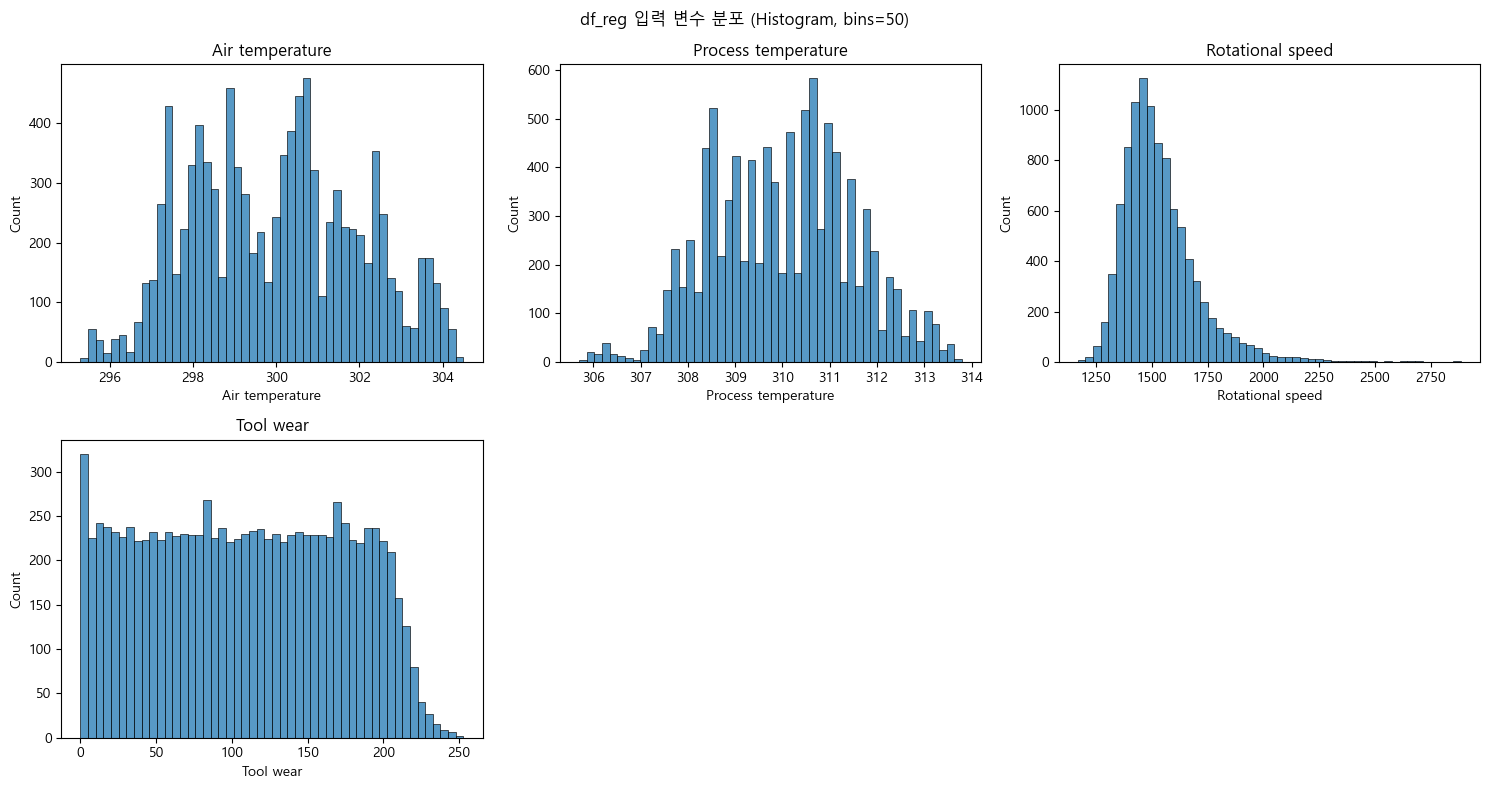

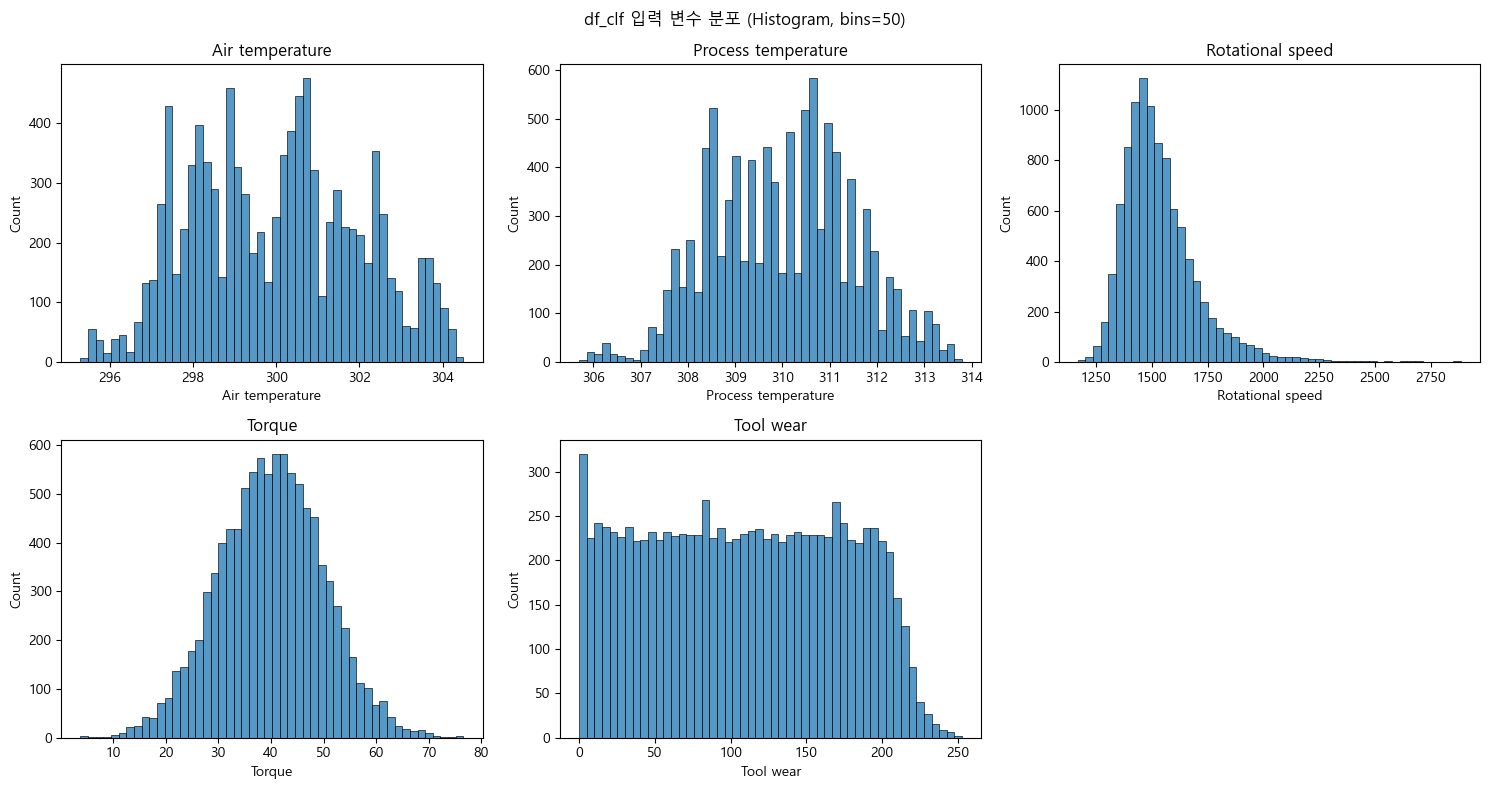

In [19]:
def plot_histograms(data, title):
    num_cols = data.select_dtypes(include='number').columns
    n_cols = 3
    n_rows = -(-len(num_cols) // n_cols)  # 올림 나누기

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, num_cols):
        sns.histplot(data=data, x=col, bins=50, ax=ax)
        ax.set_title(col)

    for ax in axes[len(num_cols):]:
        ax.axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# 회귀용 데이터셋(df_reg)의 입력 변수 분포 (타겟 Torque 제외)
plot_histograms(df_reg.drop(columns=[reg_target]), 'df_reg 입력 변수 분포 (Histogram, bins=50)')

# 분류용 데이터셋(df_clf)의 입력 변수 분포 (타겟 Machine failure 제외)
plot_histograms(df_clf.drop(columns=[clf_target]), 'df_clf 입력 변수 분포 (Histogram, bins=50)')

**[과제]** 써니는 설비 고장이 실제로 얼마나 자주 발생하는지 궁금합니다. 고장 발생 빈도를 확인할 수 있는 방법을 AI와 함께 찾아보고, 그 결과를 시각화하거나 분석해 보세요. 이 결과가 앞으로의 분석(데이터 분할, 성능 평가 등)에 어떤 영향을 줄 수 있을지도 함께 생각해 보세요.

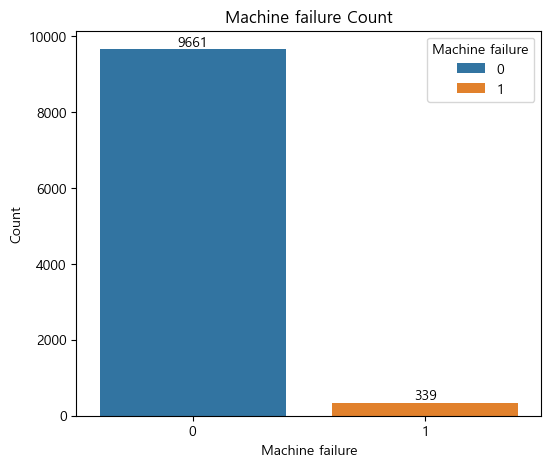

Machine failure
0    9661
1     339
Name: count, dtype: int64

고장 비율(%):
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [20]:
plt.figure(figsize=(6, 5))
plt.title('Machine failure Count')

counts = df['Machine failure'].value_counts().sort_index()   # 0, 1 순서로 정렬

sns.barplot(x=counts.index, y=counts.values, hue=counts.index)

plt.xlabel('Machine failure')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.legend(title='Machine failure')
plt.show()

print(counts)
print('\n고장 비율(%):')
print((df['Machine failure'].value_counts(normalize=True) * 100).round(2))

**[과제]** 써니는 설비가 고장 났을 때와 정상일 때 변수들의 분포가 어떻게 다른지 비교하고 싶습니다. 어떻게 비교하면 차이가 잘 드러날지 AI와 상의해서 방법을 정하고 직접 시각화해 보세요.

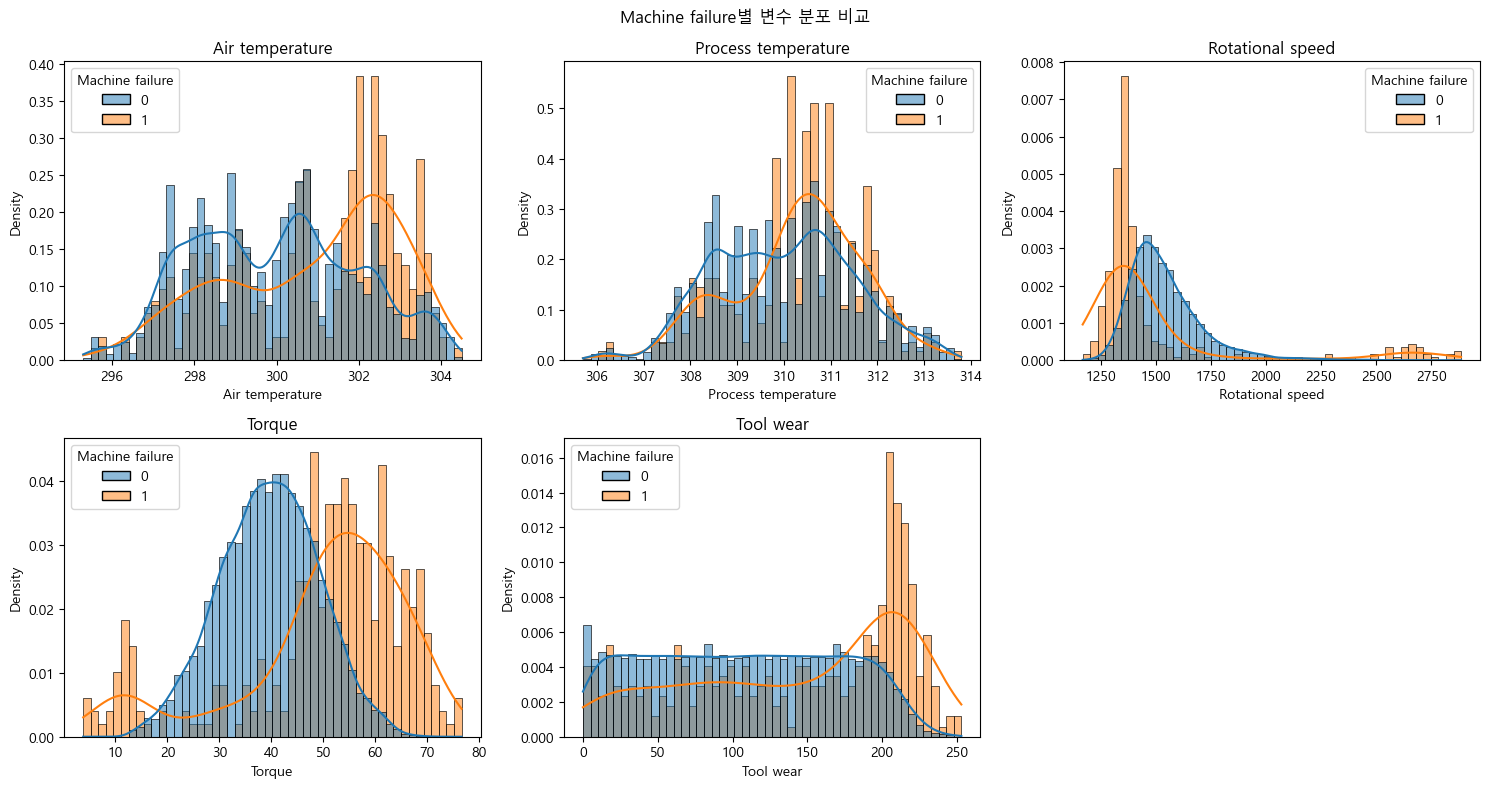

In [21]:
def plot_histograms_by_hue(data, hue_col, title):
    num_cols = [c for c in data.select_dtypes(include='number').columns if c != hue_col]
    n_cols = 3
    n_rows = -(-len(num_cols) // n_cols)  # 올림 나누기

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for ax, col in zip(axes, num_cols):
        sns.histplot(data=data, x=col, hue=hue_col, bins=50, stat='density',
                     common_norm=False, kde=True, ax=ax)
        ax.set_title(col)

    for ax in axes[len(num_cols):]:
        ax.axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# Machine failure(정상 0 / 고장 1)에 따른 df_clf 변수 분포 비교
plot_histograms_by_hue(df_clf, 'Machine failure', 'Machine failure별 변수 분포 비교')

#### 1-2-2) 변수 간 관계

**[과제]** 써니는 변수들 간에 강하게 얽혀 있는 관계(다중공선성 후보)가 있는지 한눈에 살펴보고 싶습니다. 전체 변수 간 관계를 효율적으로 볼 수 있는 방법을 AI와 상의해서 시각화해 보세요.

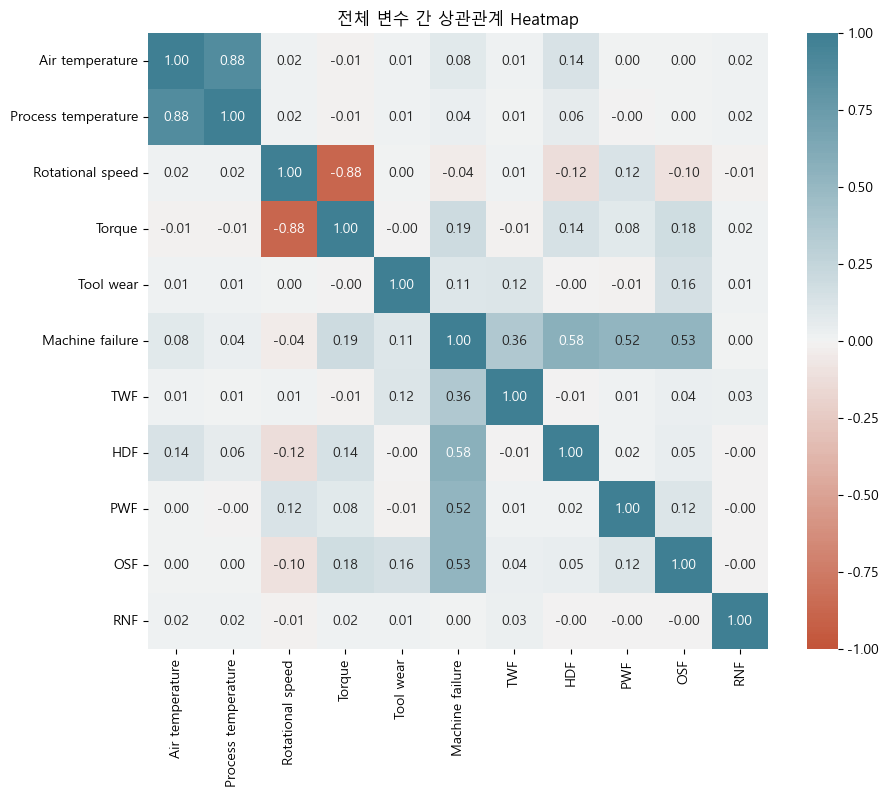

In [22]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    annot=True,        # 상관계수 숫자 표시
    fmt='.2f'          # 소수점 2자리
)

plt.title('전체 변수 간 상관관계 Heatmap')
plt.show()

**[과제]** 써니는 히트맵으로 상관관계가 높은 변수쌍은 찾았지만, 단순한 상관계수만으로 변수들이 서로 얽혀 있는 정도를 다 설명할 수 있을지 의문이 듭니다. 상관계수 외에 변수 간의 강한 관계를 파악할 수 있는 다른 방법이 있는지 AI와 함께 찾아보고, 직접 적용해 보세요.

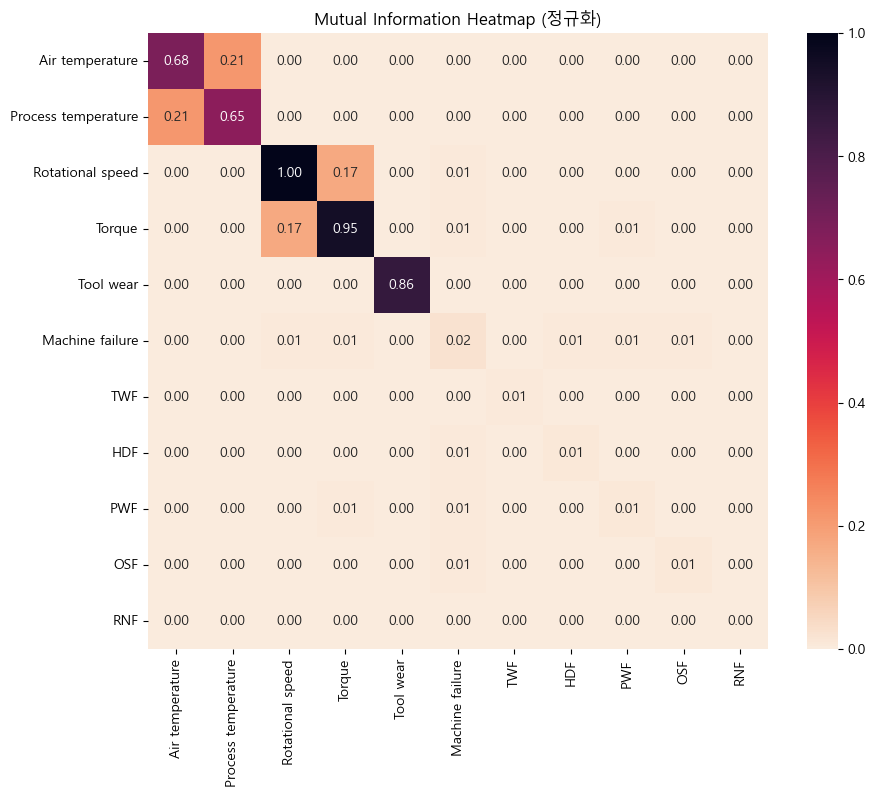

전체 변수쌍 중 관계가 강한 상위 10개 (Mutual Information 기준):


,var1,var2,pearson,spearman,kendall,mi_norm
0,Air temperature,Process temperature,0.876107,0.864217,0.685801,0.212447
19,Rotational speed,Torque,0.875027,0.916474,0.757256,0.170499
28,Torque,Machine failure,0.191321,0.169413,0.138527,0.007481
31,Torque,PWF,0.083781,0.057584,0.047086,0.006516
41,Machine failure,HDF,0.575800,0.575800,0.575800,0.006230
42,Machine failure,PWF,0.522812,0.522812,0.522812,0.005486
43,Machine failure,OSF,0.531083,0.531083,0.531083,0.005439
21,Rotational speed,Machine failure,0.044188,0.167188,0.136655,0.005378
40,Machine failure,TWF,0.362904,0.362904,0.362904,0.003573
38,Tool wear,OSF,0.155894,0.151631,0.124092,0.003385



선형 상관계수로는 놓치기 쉬운 비선형 관계 후보: 0개


,var1,var2,pearson,spearman,kendall,mi_norm


In [23]:
from sklearn.feature_selection import mutual_info_regression

num_df = df.select_dtypes(include='number')  # 범주형(Type)은 제외, 수치형 변수만 사용

# 1) Pearson: 선형 관계만 포착 (앞선 히트맵)
pearson_corr = num_df.corr(method='pearson')

# 2), 3) Spearman / Kendall: 순위 기반 -> 단조(monotonic) 비선형 관계까지 포착
spearman_corr = num_df.corr(method='spearman')
kendall_corr = num_df.corr(method='kendall')

# 4) Mutual Information: 관계의 형태(선형/비선형)에 상관없이 두 변수 간 의존성 자체를 포착 (항상 0 이상)
def mutual_info_matrix(data):
    cols = data.columns
    mi_df = pd.DataFrame(index=cols, columns=cols, dtype=float)
    for col in cols:
        mi_df[col] = mutual_info_regression(data, data[col], random_state=0)
    mi_df = (mi_df + mi_df.T) / 2   # 계산 방향(X->Y vs Y->X)에 따른 오차를 보정하기 위해 대칭화
    np.fill_diagonal(mi_df.values, np.nan)
    return mi_df

mi_matrix = mutual_info_matrix(num_df)
mi_matrix_norm = mi_matrix / mi_matrix.max().max()  # 히트맵에서 상관계수(-1~1)와 비교하기 쉽도록 0~1로 정규화

# Mutual Information 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(mi_matrix_norm, vmin=0, vmax=1, cmap='rocket_r', annot=True, fmt='.2f')
plt.title('Mutual Information Heatmap (정규화)')
plt.show()

# 네 가지 지표를 변수쌍(long format) 하나의 표로 정리해서 종합 비교
def corr_to_long(mat, name):
    m = mat.copy()
    np.fill_diagonal(m.values, np.nan)
    upper = m.where(np.triu(np.ones(m.shape, dtype=bool), k=1))
    long = upper.stack()
    long.name = name
    return long

summary = pd.concat([
    corr_to_long(pearson_corr, 'pearson').abs(),
    corr_to_long(spearman_corr, 'spearman').abs(),
    corr_to_long(kendall_corr, 'kendall').abs(),
    corr_to_long(mi_matrix_norm, 'mi_norm'),
], axis=1)
summary.index.names = ['var1', 'var2']
summary = summary.reset_index()

print('전체 변수쌍 중 관계가 강한 상위 10개 (Mutual Information 기준):')
display(summary.sort_values('mi_norm', ascending=False).head(10))

# Pearson(선형)으로는 약하게 나오지만 Spearman/MI(비선형 포함)로는 강하게 나오는 변수쌍
# -> 상관계수 히트맵만 봤을 때 놓치기 쉬운 "숨은 비선형 관계" 후보
STRONG_THRESHOLD = 0.5   # Spearman/MI 기준 "강하다"고 볼 임계값
WEAK_THRESHOLD = 0.3     # Pearson 기준 "약하다"고 볼 임계값

nonlinear_only = summary[
    (summary['pearson'] < WEAK_THRESHOLD) &
    ((summary['spearman'] >= STRONG_THRESHOLD) | (summary['mi_norm'] >= STRONG_THRESHOLD))
].sort_values('mi_norm', ascending=False)

print(f"\n선형 상관계수로는 놓치기 쉬운 비선형 관계 후보: {len(nonlinear_only)}개")
nonlinear_only

---
## 2) 데이터 전처리

### 2-1) 불필요한 변수 제거 및 결측치 확인

**[과제]** 써니는 모델에 넣기 전에 분석에 도움이 안 되거나, 오히려 결과를 왜곡시킬 수 있는 변수가 있는지 점검하려고 합니다. 어떤 변수를 빼야 하는지, 그 이유는 무엇인지 AI와 상의해서 정리하고 제거해 보세요.

In [25]:
# 제거 후보 판단 기준
# 1) 상수 변수  : 고유값이 1개뿐인 변수 -> 모든 데이터가 같은 값이라 예측에 정보를 주지 못함
# 2) 중복 변수  : 다른 변수와 값이 완전히 동일한 변수 -> 같은 정보를 중복해서 가짐
# 3) 다중공선성 : 입력 변수끼리 상관관계가 매우 높은 쌍(>= 0.8) -> 두 변수가 사실상 같은 정보를 담고 있어
#                모델을 불안정하게 만들 수 있음 (1-2-2에서 확인한 후보를 여기서 실제로 처리)
#                -> 쌍 중 타겟과의 상관관계가 더 낮은 변수를 제거 대상으로 선정

CORR_THRESHOLD = 0.8

def find_cols_to_drop(data, target):
    features = data.drop(columns=[target])

    constant_cols = features.columns[features.nunique() == 1].tolist()
    duplicate_cols = features.columns[features.T.duplicated()].tolist()

    num_features = features.select_dtypes(include='number')
    corr = num_features.corr().abs()
    target_relevance = num_features.corrwith(data[target]).abs()

    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    collinear_cols = set()
    for v1 in upper.index:
        for v2 in upper.columns:
            value = upper.loc[v1, v2]
            if pd.notna(value) and value >= CORR_THRESHOLD:
                drop_col = v1 if target_relevance[v1] < target_relevance[v2] else v2
                collinear_cols.add(drop_col)
                print(f"  - {v1} <-> {v2} 상관계수 {value:.3f} (>= {CORR_THRESHOLD}) -> '{drop_col}' 제거 후보 (타겟과의 상관관계가 더 낮음)")

    return sorted(set(constant_cols) | set(duplicate_cols) | collinear_cols), constant_cols, duplicate_cols

print('=== df_reg 점검 (target: Torque) ===')
drop_cols_reg, const_reg, dup_reg = find_cols_to_drop(df_reg, reg_target)
print('상수 변수:', const_reg)
print('중복 변수:', dup_reg)
print('최종 제거 대상:', drop_cols_reg)

print('\n=== df_clf 점검 (target: Machine failure) ===')
drop_cols_clf, const_clf, dup_clf = find_cols_to_drop(df_clf, clf_target)
print('상수 변수:', const_clf)
print('중복 변수:', dup_clf)
print('최종 제거 대상:', drop_cols_clf)

=== df_reg 점검 (target: Torque) ===
  - Air temperature <-> Process temperature 상관계수 0.876 (>= 0.8) -> 'Air temperature' 제거 후보 (타겟과의 상관관계가 더 낮음)
상수 변수: []
중복 변수: []
최종 제거 대상: ['Air temperature']

=== df_clf 점검 (target: Machine failure) ===
  - Air temperature <-> Process temperature 상관계수 0.876 (>= 0.8) -> 'Process temperature' 제거 후보 (타겟과의 상관관계가 더 낮음)
  - Rotational speed <-> Torque 상관계수 0.875 (>= 0.8) -> 'Rotational speed' 제거 후보 (타겟과의 상관관계가 더 낮음)
상수 변수: []
중복 변수: []
최종 제거 대상: ['Process temperature', 'Rotational speed']


In [26]:
# 위에서 찾은 제거 대상 변수를 실제로 제거
df_reg = df_reg.drop(columns=drop_cols_reg)
df_clf = df_clf.drop(columns=drop_cols_clf)

print('df_reg shape:', df_reg.shape)
print('df_reg 컬럼:', df_reg.columns.tolist())

print('\ndf_clf shape:', df_clf.shape)
print('df_clf 컬럼:', df_clf.columns.tolist())

df_reg shape: (10000, 5)
df_reg 컬럼: ['Type', 'Process temperature', 'Rotational speed', 'Tool wear', 'Torque']

df_clf shape: (10000, 5)
df_clf 컬럼: ['Type', 'Air temperature', 'Torque', 'Tool wear', 'Machine failure']


### 2-2) 데이터 분할

**[과제]** 써니는 학습/테스트 데이터를 나누려고 합니다. 회귀용과 분류용 각각에 어떤 분할 방법과 기준이 적합할지 AI와 상의해서 정하고, 그 기준대로 직접 나눠 보세요.

In [27]:
# 분할 기준
# - [회귀] Torque는 연속형 타겟이라 일반적인 무작위 분할이면 충분함
# - [분류] Machine failure는 정상(0) 9,661건 vs 고장(1) 339건으로 심하게 불균형(약 3.4%)함
#          -> 무작위로만 나누면 test set에 고장 사례가 거의 안 들어갈 수도 있으므로
#             stratify 옵션으로 train/test의 클래스 비율을 원본과 동일하게 유지함

from sklearn.model_selection import train_test_split

# [회귀] 입력/타겟 분리 후 분할
X_reg = df_reg.drop(columns=[reg_target])
y_reg = df_reg[reg_target]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# [분류] 입력/타겟 분리 후 분할 (stratify로 클래스 비율 유지)
X_clf = df_clf.drop(columns=[clf_target])
y_clf = df_clf[clf_target]

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print('=== 회귀 데이터 분할 결과 ===')
print('X_reg_train:', X_reg_train.shape, ' X_reg_test:', X_reg_test.shape)

print('\n=== 분류 데이터 분할 결과 ===')
print('X_clf_train:', X_clf_train.shape, ' X_clf_test:', X_clf_test.shape)

print('\n분류 타겟 비율 (stratify 확인)')
print('전체    :', y_clf.value_counts(normalize=True).round(4).to_dict())
print('train :', y_clf_train.value_counts(normalize=True).round(4).to_dict())
print('test  :', y_clf_test.value_counts(normalize=True).round(4).to_dict())

=== 회귀 데이터 분할 결과 ===
X_reg_train: (8000, 4)  X_reg_test: (2000, 4)

=== 분류 데이터 분할 결과 ===
X_clf_train: (8000, 4)  X_clf_test: (2000, 4)

분류 타겟 비율 (stratify 확인)
전체    : {0: 0.9661, 1: 0.0339}
train : {0: 0.9661, 1: 0.0339}
test  : {0: 0.966, 1: 0.034}


### 2-3) 변수 스케일링

**[과제]** 써니는 수치형 변수들의 스케일이 제각각이라 모델 학습 전에 맞춰주고 싶습니다. 변수들의 분포를 보면서 어떤 스케일링 기법이 적합할지 AI와 상의해서 정하고 적용해 보세요.

=== 회귀(df_reg) 입력 변수 스케일링 진단 ===


,이상치비율(%),정규성p값,정규분포 근사
변수,,,
Process temperature,0.0000,0.0,No
Rotational speed,4.3375,0.0,No
Tool wear,0.0000,0.0,No



=== 분류(df_clf) 입력 변수 스케일링 진단 ===


,이상치비율(%),정규성p값,정규분포 근사
변수,,,
Air temperature,0.0,0.0000,No
Torque,0.7,0.6942,Yes
Tool wear,0.0,0.0000,No


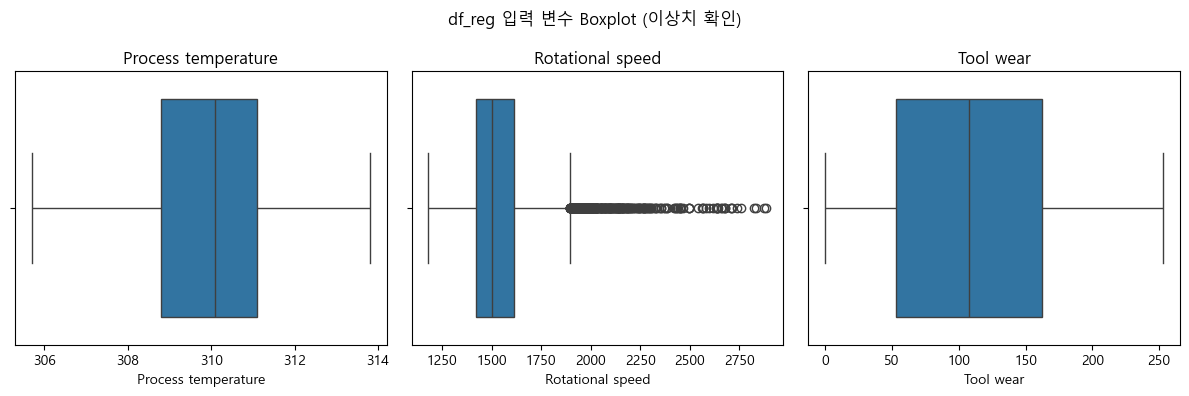

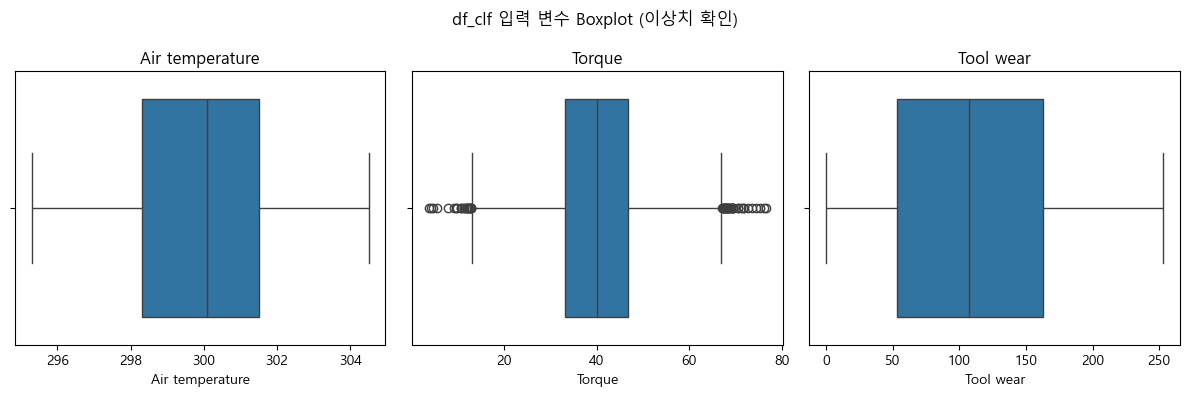


회귀(df_reg) 선택된 스케일링 기법 : minmax
분류(df_clf) 선택된 스케일링 기법 : minmax


In [30]:
from scipy import stats

# 변수별 "이상치 비율"과 "정규성"을 진단하는 함수
# - 이상치 비율 : IQR 규칙 (Q1-1.5*IQR ~ Q3+1.5*IQR 벗어나는 값의 비율)
# - 정규성      : Shapiro-Wilk 검정 (p-value >= 0.05 면 "정규분포에 가깝다"로 판단)
# * 스케일링 기준은 반드시 train 데이터로만 진단 (test는 데이터 누수 방지를 위해 사용하지 않음)
def scaling_diagnosis(X, outlier_k=1.5, alpha=0.05):
    rows = []
    for col in X.columns:
        x = X[col].dropna()

        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - outlier_k * iqr, q3 + outlier_k * iqr
        outlier_pct = ((x < lower) | (x > upper)).mean() * 100

        sample = x.sample(min(len(x), 5000), random_state=0)  # Shapiro는 표본이 크면 느리고 민감해짐
        _, p_value = stats.shapiro(sample)

        rows.append({'변수': col, '이상치비율(%)': outlier_pct, '정규성p값': p_value,
                     '정규분포 근사': 'Yes' if p_value >= alpha else 'No'})
    return pd.DataFrame(rows).set_index('변수').round(4)

num_cols_reg = X_reg_train.select_dtypes(include=['int64', 'float64']).columns
num_cols_clf = X_clf_train.select_dtypes(include=['int64', 'float64']).columns

print('=== 회귀(df_reg) 입력 변수 스케일링 진단 ===')
diagnosis_reg = scaling_diagnosis(X_reg_train[num_cols_reg])
display(diagnosis_reg)

print('\n=== 분류(df_clf) 입력 변수 스케일링 진단 ===')
diagnosis_clf = scaling_diagnosis(X_clf_train[num_cols_clf])
display(diagnosis_clf)

# 시각화로도 함께 확인 (Boxplot: 상자 밖 점 = 이상치)
fig, axes = plt.subplots(1, len(num_cols_reg), figsize=(4 * len(num_cols_reg), 4))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, num_cols_reg):
    sns.boxplot(x=X_reg_train[col], ax=ax)
    ax.set_title(col)
fig.suptitle('df_reg 입력 변수 Boxplot (이상치 확인)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(num_cols_clf), figsize=(4 * len(num_cols_clf), 4))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, num_cols_clf):
    sns.boxplot(x=X_clf_train[col], ax=ax)
    ax.set_title(col)
fig.suptitle('df_clf 입력 변수 Boxplot (이상치 확인)')
plt.tight_layout()
plt.show()

# 판단 기준
# - 이상치 비율이 높다(>=5%)  -> Standard가 안전함 (Min-Max는 이상치 하나에 나머지 값이 다 눌려버림)
# - 정규분포에 가깝다        -> Standard가 이론적 가정과 잘 맞음 (평균 0, 표준편차 1)
# - 위 둘 다 아니고 이상치도 적다 -> 굳이 정규분포를 가정할 필요 없이 Min-Max로 0~1 범위에 맞춰도 무방
OUTLIER_THRESHOLD = 5  # %

def decide_scaler(diagnosis):
    high_outlier = (diagnosis['이상치비율(%)'] >= OUTLIER_THRESHOLD).any()
    mostly_normal = (diagnosis['정규분포 근사'] == 'Yes').mean() >= 0.5
    return 'standard' if (high_outlier or mostly_normal) else 'minmax'

scaler_choice_reg = decide_scaler(diagnosis_reg)
scaler_choice_clf = decide_scaler(diagnosis_clf)

print(f"\n회귀(df_reg) 선택된 스케일링 기법 : {scaler_choice_reg}")
print(f"분류(df_clf) 선택된 스케일링 기법 : {scaler_choice_clf}")

In [29]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

def get_scaler(name):
    return StandardScaler() if name == 'standard' else MinMaxScaler()

# 스케일링 기준(fit)은 반드시 train에서만 생성 -> test에는 train 기준을 적용(transform)만 함
# test까지 사용해 기준을 만들면 모델이 미리 정보를 참고하는 데이터 누수(Data Leakage)가 발생함

# [회귀] 위에서 진단한 결과에 따라 선택된 스케일러 적용
X_reg_train_scaled = X_reg_train.copy()
X_reg_test_scaled = X_reg_test.copy()

scaler_reg = get_scaler(scaler_choice_reg)
X_reg_train_scaled[num_cols_reg] = scaler_reg.fit_transform(X_reg_train[num_cols_reg])
X_reg_test_scaled[num_cols_reg] = scaler_reg.transform(X_reg_test[num_cols_reg])

# [분류] 위에서 진단한 결과에 따라 선택된 스케일러 적용
X_clf_train_scaled = X_clf_train.copy()
X_clf_test_scaled = X_clf_test.copy()

scaler_clf = get_scaler(scaler_choice_clf)
X_clf_train_scaled[num_cols_clf] = scaler_clf.fit_transform(X_clf_train[num_cols_clf])
X_clf_test_scaled[num_cols_clf] = scaler_clf.transform(X_clf_test[num_cols_clf])

print(f"df_reg ({scaler_choice_reg}) 스케일링 결과:")
display(X_reg_train_scaled.head())

print(f"\ndf_clf ({scaler_choice_clf}) 스케일링 결과:")
display(X_clf_train_scaled.head())

df_reg (minmax) 스케일링 결과:


,Type,Process temperature,Rotational speed,Tool wear
9254,L,0.419753,0.255132,0.770751
1561,L,0.333333,0.121408,0.541502
1670,L,0.259259,0.203519,0.766798
6087,M,0.629630,0.245161,0.027668
6669,L,0.592593,0.228739,0.822134



df_clf (minmax) 스케일링 결과:


,Type,Air temperature,Torque,Tool wear
4058,M,0.728261,0.596154,0.213439
1221,M,0.184783,0.585165,0.521739
6895,M,0.619565,0.574176,0.541502
9863,L,0.391304,0.721154,0.332016
8711,L,0.195652,0.342033,0.197628


**[과제]** 써니는 `Type` 변수를 모델에 넣으려면 숫자로 바꿔야 한다는 건 알고 있지만, 원-핫 인코딩과 라벨 인코딩 중 어느 쪽이 맞을지 고민입니다. 어떤 기준으로 선택해야 할지 AI와 상의해서 정하고 적용해 보세요.

In [31]:
# 판단 기준
# - One-hot Encoding : 범주 간 순서가 없을 때 적합 (예: 공정 장비 종류) -> 순서를 매기면 모델이 잘못된 크기 관계를 학습함
# - Label(Ordinal) Encoding : 범주 간 순서가 있을 때 적합 (예: 품질 등급) -> 순서 정보를 그대로 살릴 수 있음
#
# Type은 "L(Low) < M(Medium) < H(High)"라는 명확한 품질 등급 순서를 가진 순서형(ordinal) 변수임
# -> One-hot으로 인코딩하면 이 순서 정보가 사라지고 불필요하게 컬럼 수만 늘어남
# -> 순서를 보존할 수 있는 Label(Ordinal) Encoding이 더 적합함
# * sklearn의 LabelEncoder는 알파벳순(H,L,M -> 0,1,2)으로 부여해 순서가 뒤틀리므로,
#   순서를 직접 지정하는 map을 사용함

type_order = {'L': 0, 'M': 1, 'H': 2}

print('Type 인코딩 매핑:', type_order)

# [회귀] Type 인코딩 적용
X_reg_train_scaled['Type'] = X_reg_train_scaled['Type'].map(type_order)
X_reg_test_scaled['Type'] = X_reg_test_scaled['Type'].map(type_order)

# [분류] Type 인코딩 적용
X_clf_train_scaled['Type'] = X_clf_train_scaled['Type'].map(type_order)
X_clf_test_scaled['Type'] = X_clf_test_scaled['Type'].map(type_order)

print('\ndf_reg 인코딩 결과:')
display(X_reg_train_scaled.head())

print('\ndf_clf 인코딩 결과:')
display(X_clf_train_scaled.head())

Type 인코딩 매핑: {'L': 0, 'M': 1, 'H': 2}

df_reg 인코딩 결과:


,Type,Process temperature,Rotational speed,Tool wear
9254,0,0.419753,0.255132,0.770751
1561,0,0.333333,0.121408,0.541502
1670,0,0.259259,0.203519,0.766798
6087,1,0.629630,0.245161,0.027668
6669,0,0.592593,0.228739,0.822134



df_clf 인코딩 결과:


,Type,Air temperature,Torque,Tool wear
4058,1,0.728261,0.596154,0.213439
1221,1,0.184783,0.585165,0.521739
6895,1,0.619565,0.574176,0.541502
9863,0,0.391304,0.721154,0.332016
8711,0,0.195652,0.342033,0.197628


---
## 3) 모델링

### 3-1) 모델 생성 및 학습

**[과제]** 써니는 여러 모델의 성능을 한 번에 비교해보고 싶습니다. 회귀와 분류 각각 어떤 모델을 후보로 둘지, 매번 코드를 새로 짜지 않고 효율적으로 비교할 방법은 무엇일지 AI와 상의해서 코드를 작성해 보세요.

In [32]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               GradientBoostingRegressor, GradientBoostingClassifier)
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

# task('regression' 또는 'classification')만 넣으면 해당 태스크의 후보 모델 딕셔너리를 돌려주는 함수
# -> 매번 모델을 새로 나열하지 않고, 이 함수 하나로 회귀/분류 후보 모델을 일관되게 가져올 수 있음
def get_candidate_models(task, random_state=0):
    if task == 'regression':
        return {
            'LinearRegression': LinearRegression(),                              # 기본 베이스라인
            'Ridge': Ridge(random_state=random_state),                          # 선형 + L2 규제
            'Lasso': Lasso(random_state=random_state),                          # 선형 + L1 규제 (변수 선택 효과)
            'DecisionTree': DecisionTreeRegressor(random_state=random_state),   # 비선형, 해석 용이
            'RandomForest': RandomForestRegressor(random_state=random_state),   # 트리 배깅 앙상블
            'GBM': GradientBoostingRegressor(random_state=random_state),        # 트리 부스팅 앙상블
            'XGBoost': XGBRegressor(random_state=random_state),                 # 부스팅 (속도/성능 개선)
            'LGBM': LGBMRegressor(random_state=random_state, verbose=-1),       # 부스팅 (대용량에 빠름)
            'CatBoost': CatBoostRegressor(random_state=random_state, verbose=0),# 부스팅 (범주형 변수에 강함)
        }
    elif task == 'classification':
        return {
            'Logistic': LogisticRegression(max_iter=1000),                                    # 기본 베이스라인
            'DecisionTree': DecisionTreeClassifier(random_state=random_state),                # 비선형, 해석 용이
            'RandomForest': RandomForestClassifier(random_state=random_state),                # 트리 배깅 앙상블
            'GBM': GradientBoostingClassifier(random_state=random_state),                     # 트리 부스팅 앙상블
            'XGBoost': XGBClassifier(random_state=random_state, eval_metric='logloss'),       # 부스팅 (속도/성능 개선)
            'LGBM': LGBMClassifier(random_state=random_state, verbose=-1),                    # 부스팅 (대용량에 빠름)
            'CatBoost': CatBoostClassifier(random_state=random_state, verbose=0),              # 부스팅 (범주형 변수에 강함)
        }
    else:
        raise ValueError("task는 'regression' 또는 'classification' 중 하나여야 합니다.")

# 후보 모델 생성
reg_models = get_candidate_models('regression')
cla_models = get_candidate_models('classification')

print('회귀 후보 모델:', list(reg_models.keys()))
print('분류 후보 모델:', list(cla_models.keys()))

회귀 후보 모델: ['LinearRegression', 'Ridge', 'Lasso', 'DecisionTree', 'RandomForest', 'GBM', 'XGBoost', 'LGBM', 'CatBoost']
분류 후보 모델: ['Logistic', 'DecisionTree', 'RandomForest', 'GBM', 'XGBoost', 'LGBM', 'CatBoost']


In [33]:
# 딕셔너리 형태로 모아둔 후보 모델을 순회하며 한 번에 학습
# -> 모델을 하나씩 추가/제거해도 이 반복문 코드는 그대로 재사용 가능

for name, model in reg_models.items():
    model.fit(X_reg_train_scaled, y_reg_train)
    print(f'[회귀] {name} 학습 완료')

for name, model in cla_models.items():
    model.fit(X_clf_train_scaled, y_clf_train)
    print(f'[분류] {name} 학습 완료')

[회귀] LinearRegression 학습 완료
[회귀] Ridge 학습 완료
[회귀] Lasso 학습 완료
[회귀] DecisionTree 학습 완료
[회귀] RandomForest 학습 완료
[회귀] GBM 학습 완료
[회귀] XGBoost 학습 완료
[회귀] LGBM 학습 완료
[회귀] CatBoost 학습 완료
[분류] Logistic 학습 완료
[분류] DecisionTree 학습 완료
[분류] RandomForest 학습 완료
[분류] GBM 학습 완료
[분류] XGBoost 학습 완료
[분류] LGBM 학습 완료
[분류] CatBoost 학습 완료


### 3-2) 테스트 데이터 예측

**[과제]** 써니는 앞서 학습시킨 회귀 및 분류 모델들로 테스트 데이터에 대한 예측을 수행하려고 합니다. 모든 모델의 예측 결과를 한 번에 뽑을 수 있도록 AI와 함께 코드를 작성해 보세요.

In [35]:
# [회귀] 테스트 데이터에 대한 예측
reg_preds = {}
for name, model in reg_models.items():
    reg_preds[name] = model.predict(X_reg_test_scaled)   # 테스트 입력변수로 예측
print('회귀 예측 완료 모델:', list(reg_preds.keys()))

# [분류] 테스트 데이터에 대한 예측
cla_preds = {}   # 클래스 예측값
cla_probs = {}   # 양성(1) 클래스일 확률값
for name, model in cla_models.items():
    cla_preds[name] = model.predict(X_clf_test_scaled)               # 클래스 예측
    cla_probs[name] = model.predict_proba(X_clf_test_scaled)[:, 1]   # 양성 확률 ([:,1]은 1번 클래스 확률)
print('분류 예측 완료 모델:', list(cla_preds.keys()))

회귀 예측 완료 모델: ['LinearRegression', 'Ridge', 'Lasso', 'DecisionTree', 'RandomForest', 'GBM', 'XGBoost', 'LGBM', 'CatBoost']
분류 예측 완료 모델: ['Logistic', 'DecisionTree', 'RandomForest', 'GBM', 'XGBoost', 'LGBM', 'CatBoost']


### 3-3) 성능 평가

**[과제]** 써니는 모델 성능을 비교하려고 하는데, 회귀와 분류 각각 사용할 수 있는 지표가 다양해서 무엇을 기준으로 봐야 할지 고민입니다. 적절한 지표를 AI와 상의해서 정하고, 그 기준으로 가장 좋은 모델을 선택해 보세요.

In [36]:
# [회귀 성능지표] MAE, MSE, MAPE를 계산해 딕셔너리로 반환
def get_reg_score(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)                   # 평균 절대 오차
    mse = mean_squared_error(y_true, y_pred)                    # 평균 제곱 오차
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100    # 평균 절대 백분율 오차(%)
    return {"MAE": mae, "MSE": mse, "MAPE(%)": mape}
# [분류 성능지표] 혼동행렬에서 지표를 뽑아 딕셔너리로 반환
def get_cla_score(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()   # 혼동행렬 4칸 분해
    recall = recall_score(y_true, y_pred)         # 재현율(민감도): 실제 양성 중 맞춘 비율
    specificity = tn / (tn + fp)                  # 특이도: 실제 음성 중 맞춘 비율
    return {
        "Accuracy": accuracy_score(y_true, y_pred),    # 정확도
        "Recall": recall,                               # 재현율
        "Precision": precision_score(y_true, y_pred),   # 정밀도
        "Specificity": specificity,                     # 특이도
        "F1": f1_score(y_true, y_pred),                 # 정밀도·재현율 조화평균
        "G-Mean": np.sqrt(recall * specificity),        # 재현율·특이도 기하평균(불균형 대응)
        "AUC": roc_auc_score(y_true, y_prob),           # ROC 곡선 아래 면적
    }

In [37]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score, confusion_matrix)
def get_reg_score(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"MAE": mae, "MSE": mse, "MAPE(%)": mape}
def get_cla_score(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = recall_score(y_true, y_pred)
    specificity = tn / (tn + fp)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Recall": recall,
        "Precision": precision_score(y_true, y_pred),
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred),
        "G-Mean": np.sqrt(recall * specificity),
        "AUC": roc_auc_score(y_true, y_prob),
    }
# 성능 평가 - 회귀 (MAE 기준 오름차순 정렬: 오차가 작은 모델이 위로)
reg_results = {name: get_reg_score(y_reg_test, reg_preds[name]) for name in reg_models}
reg_score_df = pd.DataFrame(reg_results).T.round(4).sort_values("MAE")
display(reg_score_df)
# 성능 평가 - 분류 (F1 기준 내림차순 정렬: 성능이 좋은 모델이 위로)
cla_results = {name: get_cla_score(y_clf_test, cla_preds[name], cla_probs[name]) for name in cla_models}
cla_score_df = pd.DataFrame(cla_results).T.round(4).sort_values("F1", ascending=False)
display(cla_score_df)
# 가장 좋은 모델 선택
best_reg_name = reg_score_df.index[0]                 # MAE가 가장 낮은 모델
best_cla_name = cla_score_df.index[0]                 # F1이 가장 높은 모델
best_reg_model = reg_models[best_reg_name]
best_cla_model = cla_models[best_cla_name]
print(f"[회귀] 최적 모델: {best_reg_name} (MAE={reg_score_df.loc[best_reg_name, 'MAE']})")
print(f"[분류] 최적 모델: {best_cla_name} (F1={cla_score_df.loc[best_cla_name, 'F1']})")

,MAE,MSE,MAPE(%)
GBM,2.9920,16.0762,7.3039
LGBM,3.0343,16.6806,7.4706
CatBoost,3.0425,16.7825,7.4920
XGBoost,3.1383,17.7503,7.7697
RandomForest,3.1384,17.3908,7.6687
LinearRegression,3.6833,23.9576,10.2971
Ridge,3.6972,24.0064,10.3004
DecisionTree,4.1590,30.5678,10.1012
Lasso,7.9050,98.5663,23.1519


c:\Users\Admin\Miniconda3\envs\day4\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Accuracy,Recall,Precision,Specificity,F1,G-Mean,AUC
GBM,0.9775,0.4412,0.8108,0.9964,0.5714,0.6630,0.9432
RandomForest,0.9765,0.4118,0.8000,0.9964,0.5437,0.6405,0.9165
LGBM,0.9760,0.3971,0.7941,0.9964,0.5294,0.6290,0.9376
CatBoost,0.9765,0.3824,0.8387,0.9974,0.5253,0.6175,0.9514
XGBoost,0.9725,0.4118,0.6512,0.9922,0.5045,0.6392,0.9332
DecisionTree,0.9675,0.4412,0.5263,0.9860,0.4800,0.6596,0.7136
Logistic,0.9660,0.0000,0.0000,1.0000,0.0000,0.0000,0.8341


[회귀] 최적 모델: GBM (MAE=2.992)
[분류] 최적 모델: GBM (F1=0.5714)


---
## 4) 모델 고도화

**[과제]** 써니는 가장 성능이 좋았던 모델을 더 끌어올리고 싶습니다. 어떤 하이퍼파라미터를 어느 범위까지 탐색하면 좋을지 AI와 상의해서 정하고, 그 기준으로 성능을 높여 보세요.

---
## 5) 모델 결과 분석

**[과제]** 써니는 최종적으로 어떤 운전 조건이 토크와 고장에 가장 큰 영향을 미치는지 정리해서 보고하려고 합니다. 회귀와 분류 각각에서 성능이 가장 좋았던 모델의 변수 중요도를 구하고 시각화하는 방법을 AI와 함께 알아본 뒤, 그 결과로부터 인사이트를 도출해 보세요.